Failure to parse tags from meshio.


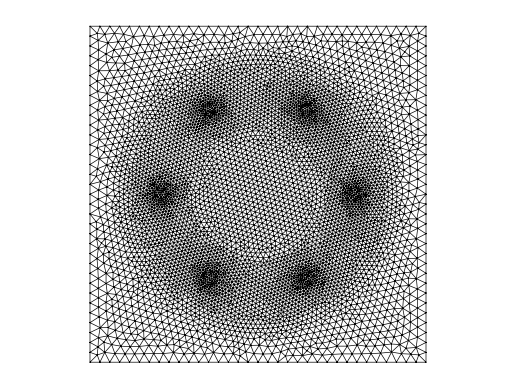

In [4]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio


m = meshio.read("../meshes/three_phase_stator.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

In [15]:
e = ElementTriP1()
basis = Basis(mesh, e)
basis_air_outer = basis.with_elements(mesh.subdomains["air_outer"])
basis_air_inner = basis.with_elements(mesh.subdomains["air_inner"])
basis_iron = basis.with_elements(mesh.subdomains["iron"])

basis_ph_A_minus = basis.with_elements(mesh.subdomains["phase_1"])
basis_ph_B_plus = basis.with_elements(mesh.subdomains["phase_2"])
basis_ph_C_minus = basis.with_elements(mesh.subdomains["phase_3"])
basis_ph_A_plus = basis.with_elements(mesh.subdomains["phase_4"])
basis_ph_B_minus= basis.with_elements(mesh.subdomains["phase_5"])
basis_ph_C_plus = basis.with_elements(mesh.subdomains["phase_6"])

In [16]:
# Small debug/test  that geometry works:

# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

wire_area = area.assemble(basis_ph_A_minus)

# should be area = 0.007853981634

print("Win area: ", wire_area)

Win area:  0.0077373233282862375


In [28]:

# w.mu little coonfusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def rhs(v, w):
    return w.J * v


mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_iron = 1000 * mu0


S_mat = laplace.assemble(basis_air_inner, mu=mu_air)
S_mat += laplace.assemble(basis_air_outer, mu=mu_air)

S_mat += laplace.assemble(basis_ph_A_plus, mu=mu_air)
S_mat += laplace.assemble(basis_ph_B_minus, mu=mu_air)
S_mat += laplace.assemble(basis_ph_C_plus, mu=mu_air)
S_mat += laplace.assemble(basis_ph_A_minus, mu=mu_air)
S_mat += laplace.assemble(basis_ph_B_plus, mu=mu_air)
S_mat += laplace.assemble(basis_ph_C_minus, mu=mu_air)

S_mat += laplace.assemble(basis_iron, mu=mu_iron)


I_0 = 5000
f = 50
omega = 2*np.pi*f


T = 1/f # time for one revolution of current

t_vals = np.linspace(0, T, 10) # Lets solve between steps

ValueError: x and y must have same first dimension, but have shapes (1,) and (5649,)

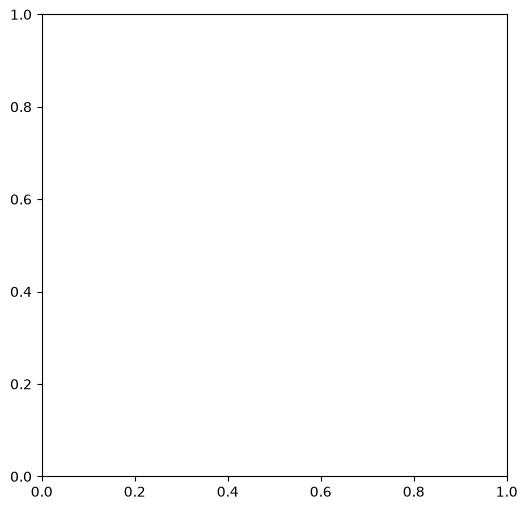

In [ ]:
# Only right hand side need to be evaluated again for each time step

from IPython.display import display, clear_output
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

for t_i in t_vals:
    I_A = I_0*np.cos(omega*t_i)
    I_B = I_0*np.cos(omega*t_i - 2*np.pi/3)
    I_C = I_0*np.cos(omega*t_i - 4*np.pi/3)

    J_A = I_A / wire_area
    J_B = I_B / wire_area
    J_C = I_C / wire_area

    # other regions dont have current
    J_iron = 0
    J_air =  0

    b = rhs.assemble(basis_air_inner, J = J_air)
    b +=  rhs.assemble(basis_air_outer, J = J_air)
    b +=  rhs.assemble(basis_iron, J = J_iron)

    b +=  rhs.assemble(basis_ph_A_plus, J = +J_A)
    b +=  rhs.assemble(basis_ph_B_minus, J = -J_B)
    b +=  rhs.assemble(basis_ph_C_plus, J = +J_C)
    b +=  rhs.assemble(basis_ph_A_minus, J = -J_A)
    b +=  rhs.assemble(basis_ph_B_plus, J = +J_B)
    b +=  rhs.assemble(basis_ph_C_minus, J = -J_C)

    S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

    A_z = solve(S_mat, b)

    ax.clear()

    plot(
        mesh,
        A_z,
        ax=ax,
        shading="gouraud",
        colorbar=False
    )

    ax.set_title(f"t = {t_i*1000:.2f} ms")
    ax.set_aspect("equal")

    clear_output(wait=True)
    display(fig)

plt.close(fig)

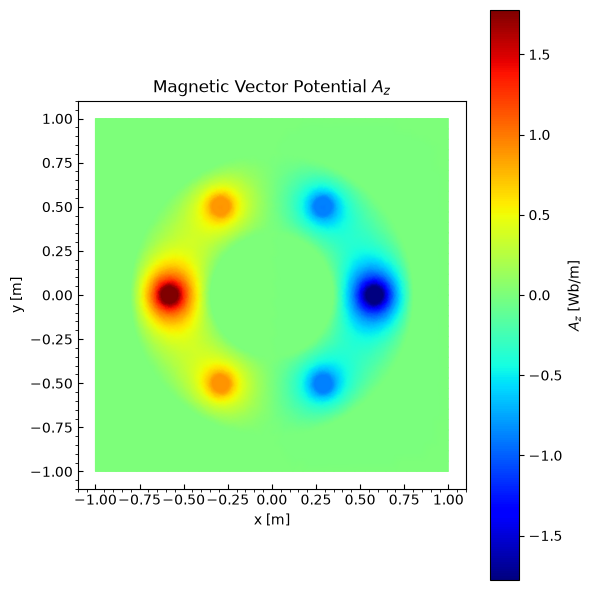

In [25]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

A_z = solve(S_mat, b)

def visualize():
    fig, ax = plt.subplots(figsize=(6, 6))

    plot(
        mesh,
        A_z,
        ax=ax,
        shading='gouraud',
        colorbar=True
    )

    ax.set_title(r"Magnetic Vector Potential $A_z$")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

    # Show coordinate ticks
    ax.tick_params(direction='in')
    ax.minorticks_on()

    # Label the colorbar
    cbar = fig.axes[-1]
    cbar.set_ylabel(r"$A_z$ [Wb/m]")

    fig.tight_layout()

if __name__ == "__main__":
    visualize()
    plt.show()